1. Import Libraries

In [21]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import(
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import(
    EarlyStopping,
    ModelCheckpoint
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

2. Load DataSet

In [22]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

3. Remove Unnecessary Column

In [23]:
df.drop("customerID", axis=1, inplace = True)

4. Handle TotalCharges

In [24]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"].isnull().sum()

np.int64(11)

5. Handle Missing Values

In [25]:
df.dropna(inplace = True)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

6. Separate Features and Target

In [26]:
x = df.drop("Churn", axis = 1)
y = df["Churn"]

7. Encode Target

In [27]:
le = LabelEncoder()
y = le.fit_transform(y)


8. Indentify Features Types

In [28]:
categorical_columns = x.select_dtypes(
    include = "object"
).columns

numerical_columns = x.select_dtypes(
    include = np.number
).columns

/var/folders/83/lyk88fr96bq5vfw5v_m3j0n40000gn/T/ipykernel_58471/1075560464.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(


9. One-Hot Encode Features

In [29]:
x = pd.get_dummies(
    x,
    columns = categorical_columns,
    drop_first = True
)

10. Train-Test Split

In [30]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

11. Feature Scaling

In [31]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# 1. Baseline Model

12. Build ANN

In [32]:
input_dim = x_train.shape[1]

model = Sequential([
    Dense(
        64,
        activation = "relu",
        input_shape = (input_dim,) 
    ),
    BatchNormalization(),
    Dropout(0.3),
    Dense(
        32,
        activation="relu"
    ),
    BatchNormalization(),
    Dropout(0.2),
    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13. Compile the Model

In [33]:
model.compile(
    optimizer = Adam(
        learning_rate = 0.001
    ),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

14. Configure Callbacks

In [34]:
#Early Stopping

early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)

#Checkpoint

checkpoint = ModelCheckpoint(
    "../models/best_ann_model.keras",
    monitor = "val_loss",
    save_best_only = True
)

15. Train the Model

In [35]:
history = model.fit(
    x_train, y_train,
    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stopping, checkpoint],
    verbose = 1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6940 - loss: 0.6113 - val_accuracy: 0.7964 - val_loss: 0.4754
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7676 - loss: 0.4920 - val_accuracy: 0.8053 - val_loss: 0.4301
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7796 - loss: 0.4713 - val_accuracy: 0.8036 - val_loss: 0.4190
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7858 - loss: 0.4575 - val_accuracy: 0.8053 - val_loss: 0.4171
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7871 - loss: 0.4520 - val_accuracy: 0.8071 - val_loss: 0.4153
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7880 - loss: 0.4462 - val_accuracy: 0.8018 - val_loss: 0.4150
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7838 - loss: 0.4401 - val_accuracy: 0.8107 - val_loss: 0.4108
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7907 - loss: 0.4398 - val_accu

16. Predict Probabilities

In [36]:
y_pred_prob = model.predict(x_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


17. Convert Probability to Class

In [37]:
y_pred = (y_pred_prob >= 0.5).astype(int)
y_pred = y_pred.flatten()

18. All Metrics

In [48]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_prob
)

19. Results Table

In [49]:
results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    })
results

,Metric,Value
0,Accuracy,0.786780
1,Precision,0.613497
2,Recall,0.534759
3,F1 Score,0.571429
4,ROC-AUC,0.835694


# 2. Architecture Optimization

1. Create build_model function

In [40]:
def build_model(hidden_layers):
    model = Sequential()

    model.add(Dense(
        hidden_layers[0],
        activation = "relu",
        input_shape = (x_train.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

2. Define Architectures

In [41]:
architectures = {
    "64-32": [64, 32],
    "128-64": [128,64],
    "32-16": [32, 16],
    "64": [64]
}

3. Train Each Model

In [46]:
results = []

for name, layers in architectures.items():
    print(f"\nTraining: {name}")
    model = build_model(layers)

    history = model.fit(
        x_train, y_train,
        validation_split = 0.2,
        epochs = 100,
        batch_size = 32,
        callbacks=[early_stopping],
        verbose = 0
    )

    y_prob = model.predict(x_test, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int).flatten()

    results.append({
        "Architecture": name,
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


Training: 64-32


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: 128-64


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: 32-16


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: 64


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4. Create Results Table

In [47]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending= False
)

,Architecture,Accuracy,Precision,Recall,F1,ROC-AUC
2,32-16,0.797441,0.646865,0.524064,0.579025,0.830470
0,64-32,0.791756,0.626959,0.534759,0.577201,0.831493
1,128-64,0.787491,0.613293,0.542781,0.575887,0.826373
3,64,0.786780,0.613497,0.534759,0.571429,0.830105


### Architecture Optimization

#### Objective
Optimized the ANN architecture by evaluating multiple hidden-layer configurations while keeping all other hyperparameters constant.

#### Architectures Evaluated
- Baseline: 64 → 32
- 128 → 64
- 32 → 16
- 64

#### Results Summary
- **32 → 16** achieved the highest Accuracy (79.74%), Precision (64.69%), and F1 Score (57.90%).
- **128 → 64** achieved the highest Recall (54.28%).
- **Baseline** achieved the highest ROC-AUC (83.57%).
- The 32 → 16 architecture provided the best overall balance between performance and model complexity.

#### Selected Architecture
**32 → 16**

#### Key Learnings
- Increasing the number of neurons does not always improve performance.
- A smaller architecture generalized better on this dataset.
- F1 Score was prioritized over Accuracy for selecting the final model.

#### Outcome
The **32 → 16** ANN architecture was selected as the optimized baseline for subsequent experiments involving optimizers, learning rates, and batch sizes.

# 3. Optimizer Comparison

1. Import Optimizers

In [50]:
from tensorflow.keras.optimizers import (
    Adam,
    RMSprop,
    SGD,
    Adamax
)

2. Modify build model

In [51]:
def build_model(hidden_layers, optimizer):
    model = Sequential()

    model.add(Dense(
        hidden_layers[0],
        activation = "relu",
        input_shape = (x_train.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

3. Define Optimizers

In [52]:
optimizers = {
    "Adam": Adam(learning_rate=0.001),
    "RMSprop": RMSprop(learning_rate=0.001),
    "SGD": SGD(learning_rate=0.001),
    "Adamax": Adamax(learning_rate=0.001)
}

4. Train Each Optimizer with best Architecture

In [53]:
best_architecture = [32, 16]

results = []

for name, optimizer in optimizers.items():

    print(f"\nTraining with {name}")

    model = build_model(best_architecture, optimizer)

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    y_prob = model.predict(x_test, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int).flatten()

    results.append({
        "Optimizer": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


Training with Adam


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with RMSprop


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with SGD


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Adamax


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5. Compare Results

In [54]:
results_df = pd.DataFrame(results)
results_df.sort_values(
    by="F1",
    ascending=False
)

,Optimizer,Accuracy,Precision,Recall,F1,ROC-AUC
0,Adam,0.798863,0.631884,0.582888,0.606398,0.835836
3,Adamax,0.796020,0.636364,0.542781,0.585859,0.834322
1,RMSprop,0.790334,0.620061,0.545455,0.580370,0.837094
2,SGD,0.783227,0.624549,0.462567,0.531490,0.826787


### Optimizer Comparison Learnings

#### Objective
Compared different optimizers to identify the best one for the selected ANN architecture.

#### Tasks Performed
- Evaluated Adam, RMSprop, SGD, and Adamax.
- Compared model performance using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
- Selected the best optimizer based on overall classification performance.

#### Key Learnings
- Adam achieved the highest F1 Score while maintaining a strong ROC-AUC.
- Different optimizers affect convergence speed and model performance.
- F1 Score was prioritized over Accuracy for selecting the final optimizer.

#### Outcome
Adam was selected as the final optimizer for the remaining optimization phases due to its balanced Precision, Recall, F1 Score, and overall performance.

# 4. Learning Rate Optimization

1. Modify build model function

In [55]:
def build_model(hidden_layers, learning_rate):
    model = Sequential()

    model.add(Dense(
        hidden_layers[0],
        activation = "relu",
        input_shape = (x_train.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate = learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

2. Create Learning Rate List

In [56]:
learning_rates = [
    0.1,
    0.01,
    0.001,
    0.0001
]

3. Train Models

In [58]:
results = []

for lr in learning_rates:

    print(f"\nTraining with Learning Rate = {lr}")

    model = build_model([32,16], lr)

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    y_prob = model.predict(x_test, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int).flatten()

    results.append({
        "Learning Rate": lr,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


Training with Learning Rate = 0.1


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Learning Rate = 0.01


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Learning Rate = 0.001


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Learning Rate = 0.0001


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4. Results Table

In [59]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
)

,Learning Rate,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.1000,0.796731,0.622905,0.596257,0.609290,0.830830
2,0.0010,0.796731,0.632530,0.561497,0.594901,0.830638
3,0.0001,0.788913,0.612903,0.558824,0.584615,0.832329
1,0.0100,0.787491,0.616822,0.529412,0.569784,0.834262


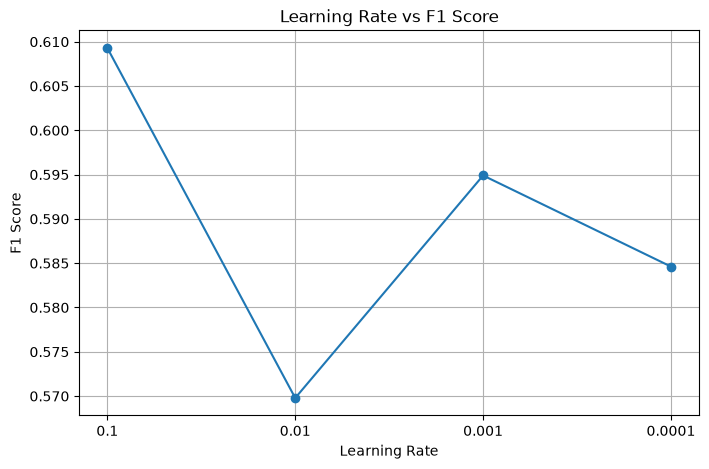

In [62]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Learning Rate"].astype(str),
    results_df["F1"],
    marker="o"
)

plt.title("Learning Rate vs F1 Score")
plt.xlabel("Learning Rate")
plt.ylabel("F1 Score")

plt.grid(True)

plt.show()

### Learning Rate Optimization Pointers

#### Objective
Optimized the learning rate of the Artificial Neural Network while keeping the architecture, optimizer, and all other hyperparameters constant.

#### Tasks Performed
- Compared four learning rates: `0.1`, `0.01`, `0.001`, and `0.0001`.
- Trained the ANN using the selected architecture (32 → 16) and Adam optimizer.
- Evaluated each model using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
- Compared the performance of each learning rate to identify the best configuration.

#### Key Learnings
- Learning rate has a significant impact on model convergence and predictive performance.
- The highest Accuracy or ROC-AUC does not always correspond to the best overall classification performance.
- For customer churn prediction, F1 Score provides a better balance between Precision and Recall than Accuracy alone.

#### Final Decision
The learning rate **0.1** was selected for the final model because it achieved the **highest F1 Score (0.6093)** while maintaining a strong ROC-AUC, making it the most suitable choice for the remaining optimization phases.

#### Outcome
The optimal learning rate was identified and finalized for the remaining ANN optimization experiments.

# 5. Batch Size Optimization

1. Update build_model

In [67]:
hidden_layers = [32,16]

learning_rate = 0.1

In [68]:
def build_model(hidden_layers):
    model = Sequential()

    model.add(Dense(
        hidden_layers[0],
        activation = "relu",
        input_shape = (x_train.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    
    model.add(Dense(1, activation="sigmoid"))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

2. Define Batch Sizes

In [69]:
batch_sizes = [16, 32, 64, 128]

3. Train Models

In [70]:
results = []

for batch in batch_sizes:

    print(f"\nTraining with Batch Size = {batch}")

    model = build_model(hidden_layers)

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=batch,
        callbacks=[early_stopping],
        verbose=0
    )

    y_prob = model.predict(x_test, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int).flatten()

    results.append({
        "Batch Size": batch,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


Training with Batch Size = 16


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Batch Size = 32


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Batch Size = 64


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Batch Size = 128


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4. Compare Results

In [72]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
)

,Batch Size,Accuracy,Precision,Recall,F1,ROC-AUC
1,32,0.788202,0.597436,0.622995,0.609948,0.834495
0,16,0.783937,0.597222,0.574866,0.585831,0.829774
3,128,0.800995,0.656667,0.526738,0.584570,0.831337
2,64,0.796020,0.638978,0.534759,0.582242,0.832663


5. Visualize

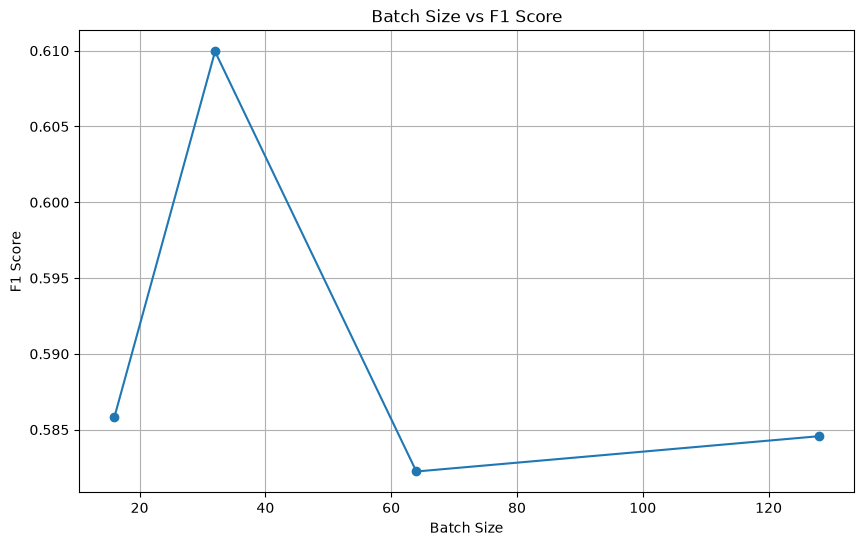

In [76]:
plt.figure(figsize=(10,6))

plt.plot(
    results_df["Batch Size"],
    results_df["F1"],
    marker="o"
)

plt.title("Batch Size vs F1 Score")
plt.xlabel("Batch Size")
plt.ylabel("F1 Score")

plt.grid(True)

plt.show()

### Batch Size Optimization Learnings

#### Objective

Optimized the batch size while keeping the selected ANN architecture, optimizer, and learning rate constant to identify the configuration that provides the best classification performance.

---

#### Hyperparameters Used

- Architecture: **32 → 16**
- Optimizer: **Adam**
- Learning Rate: **0.1**
- Epochs: **100**
- EarlyStopping: **Enabled**

Batch sizes evaluated:

- 16
- 32
- 64
- 128

---

#### Observations

- Batch Size **32** achieved the highest **F1 Score** and **ROC-AUC** among all evaluated configurations.
- Batch Size **128** produced the highest Accuracy but significantly reduced Recall, making it less suitable for customer churn prediction.
- Smaller and larger batch sizes resulted in lower F1 Scores compared to Batch Size 32.

---

#### Final Decision

**Batch Size = 32** was selected as the optimal batch size because it achieved the highest **F1 Score (0.6099)** and **ROC-AUC (0.8345)** while maintaining a balanced trade-off between Precision and Recall.

---

#### Key Learnings

- Batch size directly influences model convergence and generalization.
- Larger batch sizes do not necessarily improve model performance.
- F1 Score and ROC-AUC provide better guidance than Accuracy for selecting models in customer churn prediction.

---

#### Outcome

The optimal batch size has been finalized. The current best ANN configuration is:

- Architecture: **32 → 16**
- Optimizer: **Adam**
- Learning Rate: **0.1**
- Batch Size: **32**

This configuration will be used in the remaining optimization phases.

# 6. Decision Threshold Optimization

1. Train the Final Optimized Model

In [77]:
hidden_layers = [32,16]

learning_rate = 0.1

In [78]:
def build_model(hidden_layers):
    model = Sequential()

    model.add(Dense(
        hidden_layers[0],
        activation = "relu",
        input_shape = (x_train.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    
    model.add(Dense(1, activation="sigmoid"))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [79]:

print(f"\nTraining the Model")
model = build_model(hidden_layers)
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
    )


Training the Model


/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2. Predict Probabilities

In [80]:
y_prob = model.predict(x_test).flatten()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


3. Define Thresholds

In [87]:
thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

4. Evaluate Each Threshold

In [88]:
results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

5. Results Table

In [89]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
)

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
1,0.3,0.749112,0.519481,0.748663,0.613363,0.832769
2,0.4,0.788202,0.598958,0.614973,0.606860,0.832769
0,0.2,0.684435,0.452055,0.882353,0.597826,0.832769
3,0.5,0.794598,0.666667,0.454545,0.540541,0.832769
4,0.6,0.778252,0.696203,0.294118,0.413534,0.832769
5,0.7,0.759062,0.786885,0.128342,0.220690,0.832769


6. Plot F1 vs Threshold

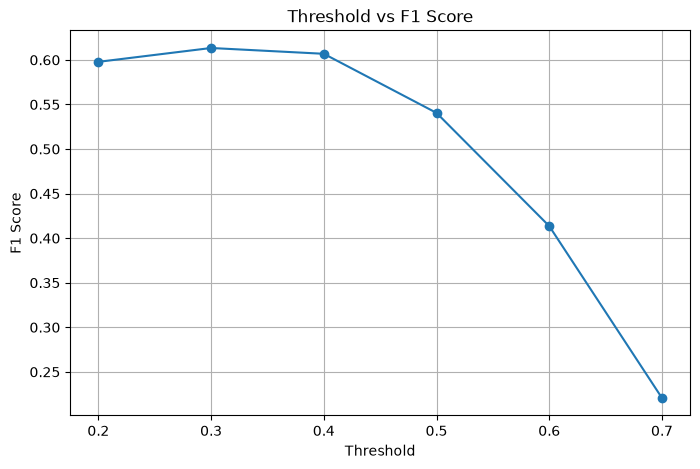

In [90]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Threshold"],
    results_df["F1"],
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")

plt.grid(True)

plt.show()

### Decision Threshold Optimization Pointers

#### Objective
Optimized the prediction threshold to achieve the best balance between Precision and Recall for customer churn prediction.

#### Tasks Performed
- Compared thresholds from 0.20 to 0.70.
- Evaluated each threshold using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
- Selected the optimal threshold based on F1 Score.

#### Final Decision
Threshold **0.30** was selected as the optimal prediction threshold because it achieved the **highest F1 Score (0.6134)** while maintaining a high **Recall (0.7487)** and a strong **ROC-AUC (0.8328)**, making it the most suitable choice for customer churn prediction.

#### Key Learnings
- Lowering the threshold improved Recall but reduced Precision.
- Increasing the threshold improved Precision but reduced Recall.
- F1 Score provided the best criterion for selecting the optimal threshold.

#### Outcome
The final ANN model will use a **prediction threshold of 0.30** for deployment and future predictions.